<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Valuing Volatility Derivatives

## Introduction

This chapter illustrates the valuation of volatility futures and options according to Gruenbichler and Longstaff (1996), also abbreviated in the following by GL96. They derive a semi-analytical ("closed") pricing formula for European volatility call options which is as easy to use as the famous Black-Scholes-Merton formula for equity options pricing. They model volatility directly and make the assumption that volatility follows a square-root diffusion process. The model is quite simple and parsimonious such that it lends itself pretty well to serve as a starting point.

This chapter introduces the financial model, the futures and option pricing formulas of Gruenbichler and Longstaff as well as a discretization of the model for Monte Carlo simulation purposes. For both, the formulas and the Monte Carlo simulation approach, Python implementations are presented. Finally, the chapter shows in detail how to calibrate the GL96 model to market quotes for European call options on the VSTOXX volatility index.

## The Valuation Framework

Gruenbichler and Longstaff (1996) model the volatility process (e.g. the process of a volatility index) in direct fashion by a square-root diffusion or CIR process &mdash; named after the authors John C. Cox, Jonathan E. Ingersoll, and Stephen A. Ross, who first introduced this type of stochastic process to finance; cf. Cox et al. (1985). The stochastic differential equation describing the evolution of the volatility over time takes on the form

$$
dv_t = \kappa (\theta - v_t)dt + \sigma \sqrt{v} dZ_t
$$

where

* $v_t$ is the time $t$ value of the volatility index, for example the VSTOXX
* $\theta$ is the long-run mean of the volatility index
* $\kappa$ is the rate at which $v_t$ reverts to $\theta$
* $\sigma$ is the volatility of the volatility ("vol-vol")
* $\theta, \kappa, \sigma$ are assumed to be constant and positive
* $Z_t$ is a standard Brownian motion

This process is known to exhibit convenient and realistic features for volatility modeling, like positivity and mean-reversion.

For the numerical examples in this chapter we use a parametrization as follows:

In [1]:
import sys
import math
## model parameters
v0 = 17.5  # initial level of volatility index
# kappa = 1  # high speed of mean reversion
kappa = 0.1  # slow speed of mean reversion
theta = 20.0  # long-term index level
sigma = 2.0  # volatility of volatility
zeta = 0.0  # factor of the expected volatility risk premium
r = 0.01  # risk-free short rate

## option parameters
K = 20.0  # strike
T = 1.0  # time horizon in year fractions

## The Futures Pricing Formula

Denote by $F(v,T)$ the futures price of a futures contract on the volatility index $v$ with maturity $T$. The pricing of such a contract is done by taking expectations of the index's value at maturity $F(v,T)=E(v_T)$. One obtains the following formula for the futures price:

$$
F(v_0,T)= \left( 1-e^{-\kappa T}  \right) \cdot \theta + e^{-\kappa T} \cdot v_0
$$

It is an exponentially weighted average of the long-run mean and the current value of the volatility index. The function ``futures_price`` implements this formula in Python, now for a general volatility risk premium $\zeta \geq 0$. 

In [2]:
sys.path.append('./scripts')
import srd_functions as srd

In [3]:
srd.futures_price??

Signature: srd.futures_price(v0, kappa, theta, zeta, T)
Source:   
def futures_price(v0, kappa, theta, zeta, T):
    ''' Futures pricing formula in GL96 model.

    Parameters
    v0: float (positive)
        current volatility level
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean of volatility
    zeta: float (positive)
        volatility risk premium
    T: float (positive)
        time-to-maturity

    Returns
    future: float
        price of a future
    '''
    alpha = kappa * theta
    beta = kappa + zeta
    future = (alpha / beta * (1 - math.exp(-beta * T))
                               + math.exp(-beta * T) * v0)
    return future
File:      ~/data/projects/lvvd/code/scripts/srd_functions.py
Type:      function

Application of the formula and function are straightforward. However, we have to first import the function from the module in which it is stored.

In [4]:
srd.futures_price(v0, kappa, theta, zeta, T)

17.7379064549101

We obtain a futures term structure by calculating the futures prices for different maturities (see the following figure).

In [5]:
import numpy as np
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'

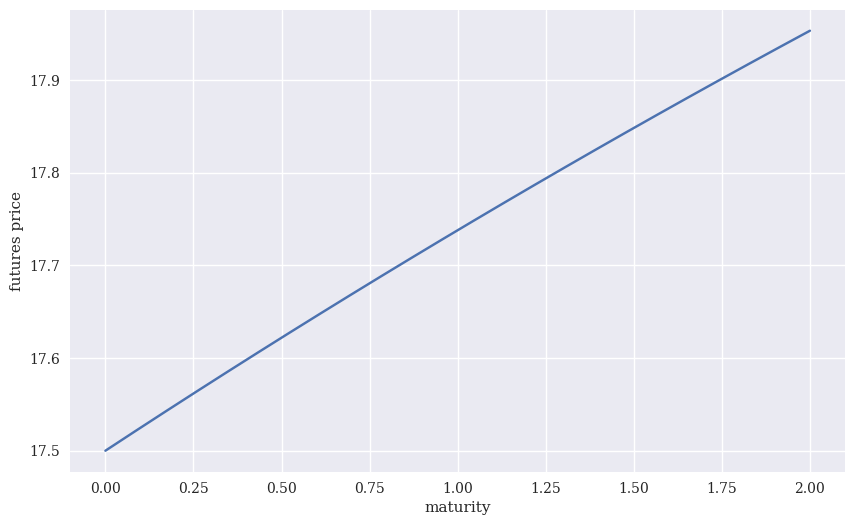

In [6]:
maturities = np.linspace(0, 2, 24)
futures_prices = [srd.futures_price(v0, kappa, theta, zeta, T)
                 for T in maturities]
plt.figure(figsize=(10, 6))
plt.plot(maturities, futures_prices)
plt.xlabel('maturity')
plt.ylabel('futures price');

<p style="font-family: monospace;">Futures prices from today to a maturity of 24 months.

## The Option Pricing Formula

A European call option on the underlying $V$ has a payoff function $\max(V_T-K,0)$ at maturity $T$ where $K$ is the strike price of the option. Gruenbichler and Longstaff (1996) derive the following pricing formula for such a call option

\begin{eqnarray*}
    C(v_0,K,T) &=& e^{-rT} \cdot e^{- \beta T} \cdot V_0 \cdot \mathbf{Q} \left(\gamma \cdot K; \nu + 4, \lambda \right)\\
    &+& e^{-rT} \cdot \left(\frac{\alpha}{\beta}\right) \cdot \left(1-e^{- \beta T}\right) \cdot \mathbf{Q}\left(\gamma \cdot K; \nu+2,  \lambda \right) \\
    &-& e^{-rT} \cdot K \cdot \mathbf{Q}\left(\gamma \cdot K; \nu, \lambda \right)
\end{eqnarray*}

where

\begin{eqnarray*}
    \alpha &=& \kappa  \theta \\
    \beta &=& \kappa + \zeta \\
    \gamma &=& \frac{4 \beta}{\sigma^2 \left(1-e^{- \beta T}\right)} \\
    \nu &=& \frac{4 \alpha}{\sigma^2} \\
    \lambda &=& \gamma \cdot e^{- \beta T} \cdot v_0
\end{eqnarray*}

and $e^{-rT}$ as the discount factor for a fixed short rate $r$. The parameter $\zeta$ denotes as before the expected premium for volatility risk. In the following, we assume $\zeta = 0$.

$\mathbf{Q}(\cdot; \nu, \lambda)$ is the complementary non-central $\chi^2$ distribution with $\nu$ degrees of freedom and non-centrality parameter $\lambda$.

In our Python implementation ``srd_functions.py`` (see the appendix for the complete module), we use the function ``ncx2.cdf()`` from the ``scipy.stats`` sub-library for the non-central $\chi^2$ distribution. We implement two different functions, a helper function and the pricing function itself:

* ``cx()``: this function returns values for the complementary distribution of the non-central chi-squared density
* ``call_price()``: the implementation of the valuation formula for European calls on the volatility index

The function ``cx()`` is as follows:

In [7]:
srd.cx??

Signature: srd.cx(K, gamma, nu, lamb)
Source:   
def cx(K, gamma, nu, lamb):
    ''' Complementary distribution function of non-central chi-squared density.

    Parameters
    K: float (positive)
        strike price
    gamma: float (positive)
        as defined in the GL96 model
    nu: float (positive)
        degrees of freedom
    lamb: float (positive)
        non-centrality parameter

    Returns
    complementary distribution of nc cs density
    '''
    return 1 - scs.ncx2.cdf(gamma * K, nu, lamb)
File:      ~/data/projects/lvvd/code/scripts/srd_functions.py
Type:      function

The function ``cx()`` is used in the valuation function ``call_price()``.

In [8]:
srd.call_price??

Signature: srd.call_price(v0, kappa, theta, sigma, zeta, T, r, K)
Source:   
def call_price(v0, kappa, theta, sigma, zeta, T, r, K):
    ''' Call option pricing formula in GL96 Model

    Parameters
    v0: float (positive)
        current volatility level
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean of volatility
    sigma: float (positive)
        volatility of volatility
    zeta: float (positive)
        volatility risk premium
    T: float (positive)
        time-to-maturity
    r: float (positive)
        risk-free short rate
    K: float(positive)
        strike price of the option

    Returns
    call: float
        present value of European call option
    '''
    D = math.exp(-r * T)  # discount factor

    alpha = kappa * theta
    beta = kappa + zeta
    gamma = 4 * beta / (sigma ** 2 * (1 - math.exp(-beta * T)))
    nu = 4 * alpha / sigma ** 2
    lamb = gamma * math.exp(-beta * T) * v0

    # the pricing form

As before, being equipped with such a Python function makes applying the pricing formula straightforward. 

In [9]:
srd.call_price(v0, kappa, theta, sigma, zeta, T, r, K)

2.2392664074205193

Let us calculate European call option prices over a wider range of strikes.

In [10]:
import pandas as pd
option_values = []
strikes = np.linspace(15, 25)
option_values = [srd.call_price(v0, kappa, theta, sigma, zeta, T, r, k)
                 for k in strikes]
data = pd.DataFrame(option_values, index=strikes,
                    columns=['call values', ])
data.index.name = 'strike'

As the following figure shows, the European call option prices behave comparable to equity options: the higher the strike price the lower the option present value ceteris paribus.

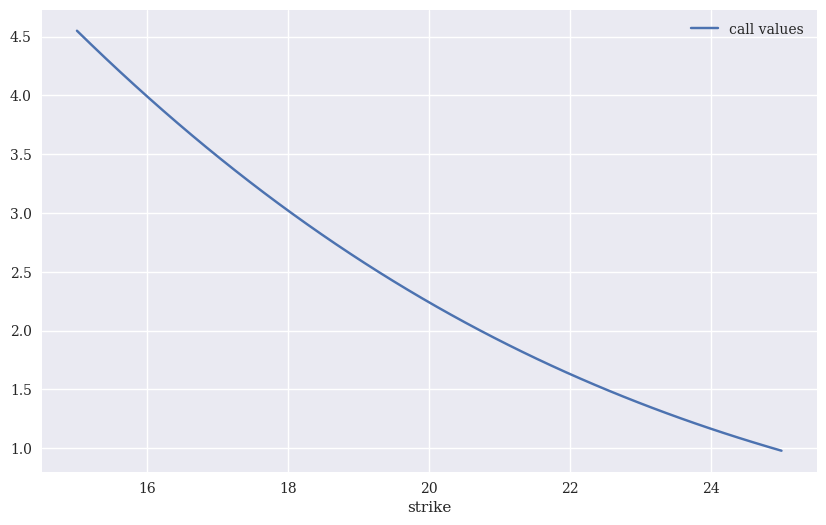

In [11]:
data.plot(figsize=(10, 6));

<p style="font-family: monospace;">European call option prices for different volatility strikes in GL96 model.

## Monte Carlo Simulation

In this section, we solve the pricing problem for a European call option via Monte Carlo simulation, i.e. based on a large number of simulated volatility index paths. To this end, we have to discretize the stochastic differential equation to obtain a difference equation which we can evaluate numerically.

We use the same numerical parameters as before, but we have to define some additional parameters which will determine the discretization interval and the number of simulated paths:

In [12]:
## simulation parameters
M = 50  # time steps
I = 20000  # number of MCS paths

There is a large literature avaible about the discretization of the square-root diffusion (cf. Hilpisch (2015), ch. 10). In the following, we will implement an exact discretization scheme.

First, we divide the time interval $[0, T]$ into $M$ time intervals with $M+1$ discrete points in time: $t \in \{0, \Delta t, 2 \Delta t , \ldots, T \}$. We have:

$$
v_t = \frac{\sigma^2 (1- e^{- \kappa \Delta t})}{4 \kappa} \tilde{\chi}^2_{\nu,\lambda} \frac{4^{- \kappa \Delta t}}{\sigma^2 (1- e^{- \kappa \Delta t})} \cdot v_s
$$

with $s = t - \Delta t$.

$\tilde{\chi}^2_{\nu,\lambda}$ denots a non-central chi-squared distributed random variable with

$$\nu = \frac{4 \theta \kappa}{\sigma^2}$$

degrees of freedom and non centrality parameter

$$\lambda = \frac{4 \kappa e^{- \kappa \Delta t}}{\sigma^2 (1- e^{- \kappa \Delta t})} \cdot v_s$$

As it may be more convenient to sample a chi-squared random variable instead of non-central chi-squared one, we use the following equations:

\begin{eqnarray*}
\nu>1 &:& \tilde{\chi}^2_{\nu,\lambda} = (z+ \sqrt{\lambda})^2 + {\chi}^2_{\nu-1} \\
\nu \le 1 &:& \tilde{\chi}^2_{\nu,\lambda} = {\chi}^2_{\nu+2P}
\end{eqnarray*}

where $z$ is an independent standard normally distributed random variable and $P$ is a Poisson distributed random variable with intensity $\frac{\lambda}{2}$.

We again divide the implementation in Python in two functions:

* ``generate_paths()`` generates simulated volatility level paths
* ``call_estimator()`` simulates the volatility process and calculates the Monte Carlo estimator for the European call option value

The function to generate simulated volatility paths takes on a form as follows.

In [13]:
srd.generate_paths??

Signature: srd.generate_paths(x0, kappa, theta, sigma, T, M, I)
Source:   
def generate_paths(x0, kappa, theta, sigma, T, M, I):
    ''' Simulation of square-root diffusion with exact discretization

    Parameters
    x0: float (positive)
        starting value
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean
    sigma: float (positive)
        volatility (of volatility)
    T: float (positive)
        time-to-maturity
    M: int
        number of time intervals
    I: int
        number of simulation paths

    Returns
    x: NumPy ndarray object
        simulated paths
    '''
    dt = float(T) / M
    x = np.zeros((M + 1, I), dtype=float)
    x[0, :] = x0
    # matrix filled with standard normal distributed rv
    ran = np.random.standard_normal((M + 1, I))
    d = 4 * kappa * theta / sigma ** 2
     # constant factor in the integrated process of x
    c = (sigma ** 2 * (1 - math.exp(-kappa * dt))) / (4 * kappa)
    if d > 

An application of this function might look as follows.

In [14]:
paths = srd.generate_paths(v0, kappa, theta, sigma, T, M, I)

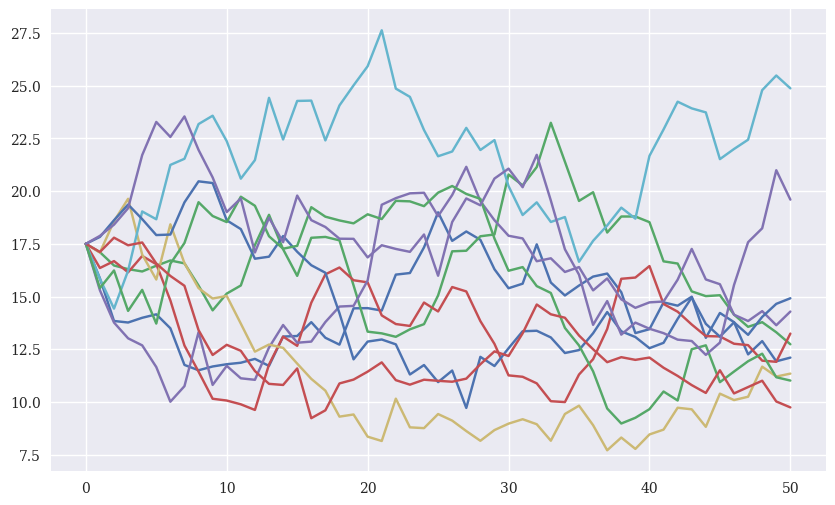

In [15]:
pd.DataFrame(paths[:, :10]).plot(legend=False, figsize=(10, 6));

<p style="font-family: monospace;">10 simulated volatility paths for GL96 model.

The Monte Carlo estimator for a European call option is defined by

$$
C(v_0,K,T) = e^{-rT}\frac{1}{I} \sum_{i=1}^{I} \max(v_T^i-K,0)
$$

with $\max(v_T-K,0)$ being the payoff function of the European call option. Here, $v_T^i$ is the $i$-th simulated value for the volatility index at maturity. The function to calculate the Monte Carlo estimator for the value of the European call option is presented below.

In [16]:
srd.call_estimator??

Signature: srd.call_estimator(v0, kappa, theta, sigma, T, r, K, M, I)
Source:   
def call_estimator(v0, kappa, theta, sigma, T, r, K, M, I):
    ''' Estimation of European call option price in GL96 Model
    via Monte Carlo simulation

    Parameters
    v0: float (positive)
        current volatility level
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean of volatility
    sigma: float (positive)
        volatility of volatility
    T: float (positive)
        time-to-maturity
    r: float (positive)
        risk-free short rate
    K: float (positive)
        strike price of the option
    M: int
        number of time intervals
    I: int
        number of simulation paths

    Returns
    callvalue: float
        MCS estimator for European call option
    '''
    V = generate_paths(v0, kappa, theta, sigma, T, M, I)
    callvalue = math.exp(-r * T) * np.sum(np.maximum(V[-1] - K, 0)) / I
    return callvalue
File:      ~/data/

In [17]:
srd.call_estimator(v0, kappa, theta, sigma, T, r, K, M, I)

2.2669300554937695

Again, let us calculate option prices over a wider range of strikes.

In [18]:
%%time
estimates = []
for k in strikes:
    estimates.append(srd.call_estimator(v0, kappa, theta, sigma,
                                    T, r, k, M, I))
data['estimates'] = estimates

CPU times: user 2.32 s, sys: 110 ms, total: 2.43 s
Wall time: 2.09 s


The following figure compares the Monte Carlo estimator values given the above parametrization with the European call option values obtained from the formula by Gruenbichler and Longstaff (1996).

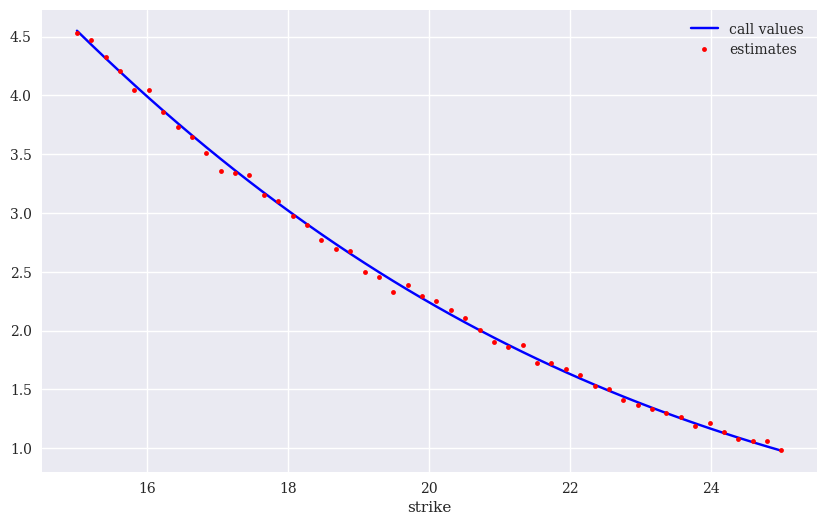

In [19]:
data.plot(style=['b', 'r.'], figsize=(10, 6));

<p style="font-family: monospace;">Monte Carlo estimates vs. European call values from formula in GL96 model.

## Automated Monte Carlo Tests

This section illustrates how to automate Monte Carlo-based valuation tests. Even if semi-analytical option pricing formulae are available &mdash; like in the Gruenbichler and Longstaff (1996) model &mdash; one needs in general numerical methods as well. One of the most flexible and powerful methods when it comes to the valuation of more complex, exotic instruments is Monte Carlo simulation (MCS).

When implementing MCS algorithms it is generally advised to benchmark the results from these algorithms against results from other valuation methods which are known to deliver exact values. Therefore, this section implements MCS for the Gruenbichler and Longstaff (1996) model and benchmarks the results against the semi-analytical formula for European volatility call options as presented earlier in this chapter.

In the previous section, MCS is already introduced and some benchmark results are presented. However, this section enhances the analysis and adds functionalities for the structured storage and systematic analysis of valuation results. In this regard, the Python library pandas is used in combination with the storage capabilities of PyTables, the Python wrapper for the HDF5 database file format.

### The Automated Testing

The following test procedures are based on the Python script ``srd_simulation_analysis.py`` (see the appendix for the complete code). To automate the valuation for a significant number of options, a set of parameter values and lists has to be specified. First, some imports and the parametrization of the financial model.

In [20]:
!sed -n 10,23p scripts/srd_simulation_analysis.py

import time
import math
import numpy as np
from datetime import datetime
from srd_functions import generate_paths, call_price
from srd_simulation_results import *

# Model Parameters
v0 = 20.0  # initial volatility
kappa = 3.0  # speed of mean reversion
theta = 20.0  # long-term volatility
sigma = 3.2  # standard deviation coefficient
zeta = 0.0  # factor of the expected volatility risk premium
r = 0.01  # risk-free short rate


The parameter values chosen are not too unrealistic, for example, for the VSTOXX volatility index. Second, the following simulation parameters are assumed.

In [21]:
!sed -n 25,38p scripts/srd_simulation_analysis.py

# General Simulation Parameters
write = True
var_red = [(False, False), (False, True), (True, False), (True, True)]
    # 1st = mo_match -- random number correction (std + mean + drift)
    # 2nd = anti_paths -- antithetic paths for variance reduction
# number of time steps
steps_list = [25, 50, 75, 100]
# number of paths per valuation
paths_list = [2500, 50000, 75000, 100000, 125000, 150000]
SEED = 100000  # seed value
runs = 3  # number of simulation runs
PY1 = 0.010  # performance yardstick 1: abs. error in currency units
PY2 = 0.010  # performance yardstick 2: rel. error in decimals
maturity_list = [1.0 / 12 , 1.0 / 4, 1.0 / 2, 1.0]  # maturity list


The single parameters and list objects have the following meaning:

* ``write`` is just a flag to indicate that the results should be stored on disk
* ``var_red`` contains the configuration for the variance reduction techniques, i.e. moment matching of pseudo-random numbers and antithetic variates
* ``steps_list`` is the list with the different numbers for the time steps to be used for the discretization
* ``paths_list`` contains the different numbers for the MCS paths for the volatility process
* ``runs`` is a parameter which says how often the same option is valued for a single parameter combination
* ``SEED`` is a seed value for NumPy's pseudo-random number generator; it is fixed to make it easier to compare results
* ``PY1`` is the performance yardstick for absolute differences
* ``PY2`` is the performance yardstick for relative differences
* ``maturity_list`` is the list with times-to-maturity
* ``strike_list`` finally is the list with the different strike prices

For details with regard to such Monte Carlo simulation analyses and the respective MCS background information refer to the book Hilpisch (2018, ch. 12). For a detailed exposition of Monte Carlo methods implemented in Python see also Hilpisch (2015, ch. 10).

The script ``srd_simulation_analysis.py`` used in this section relies on the MCS function from the previous section. In addition, it uses the following function which implements two variance reduction techniques, moment matching and antithetic variates. 

In [22]:
from srd_simulation_analysis import randoms

In [23]:
randoms??

Signature: randoms(M, I)
Source:   
def randoms(M, I):
    ''' Function to generate pseudo-random numbers with variance reduction.

    Parameters
    M: int
        number of discrete time intervals
    I: int
        number of simulated paths

    Returns
    rand: Numpy ndarray object
        object with pseudo-random numbers
    '''
    if anti_paths is True:
        rand_ = np.random.standard_normal((M + 1, int(I / 2)))
        rand = np.concatenate((rand_, -rand_), 1)
    else:
        rand = np.random.standard_normal((M + 1, I))
    if mo_match is True:
        rand = rand / np.std(rand)
        rand = rand - np.mean(rand)
    return rand
File:      ~/data/projects/lvvd/code/scripts/srd_simulation_analysis.py
Type:      function

The main valuation and testing loop is implemented through the following code. Important passages are commented inline.

In [24]:
!sed -n 116,191p scripts/srd_simulation_analysis.py

if __name__ == '__main__':
    t0 = time.time()
    sim_results = pd.DataFrame()

    for vr in var_red:  # variance reduction techniques
        mo_match, anti_paths = vr
        for M in steps_list:  # number of time steps
            for I in paths_list:  # number of paths
                t1 = time.time()
                d1 = datetime.now()
                abs_errors = []
                rel_errors = []
                l = 0.0
                errors = 0
                # name of the simulation setup
                name = ('Call_' + str(runs) + '_'
                        + str(M) + '_' + str(I / 1000)
                        + '_' + str(mo_match)[0] + str(anti_paths)[0] +
                        '_' + str(PY1 * 100) + '_' + str(PY2 * 100))
                np.random.seed(SEED)  # RNG seed value
                for run in range(runs):  # simulation runs
                    print("\nSimulation Run %d of %d" % (run + 1, runs))
                    print("--------------------------------

### The Storage Functions

The script ``srd_simulation_analysis.py`` from the previous sub-section generates a number of results and a lot of printed output during execution. However, one generally wants to store such results in a structured manner and analyze it maybe later on.  To this end, we use the pandas library which provides convenient data storage and analysis features. In combination with the PyTables library, simulation results are easily stored on disk and read from disk later on.

Consider now the Python module ``srd_simulation_results.py`` with several functions to store and analyze the data generated through the other script (see the appendix for the complete script). We will go through this script part by part. Of course, there are some necesary imports and a filename for the database is also specified:

In [25]:
!sed -n 11,17p scripts/srd_simulation_results.py

import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# filname for HDFStore to save results
filename = "data/simulation_results.h5"


Having a ``DataFrame`` object instantiated (with results already stored or not), the following function allows to add a set of valuation results to the ``DataFrame`` as an additional row.

In [26]:
import srd_simulation_results as ssr

In [27]:
ssr.write_results??

Signature:
ssr.write_results(
    sim_results,
    name,
    SEED,
    runs,
    steps,
    paths,
    mo_match,
    anti_paths,
    l,
    PY1,
    PY2,
    errors,
    error_ratio,
    abs_errors,
    rel_errors,
    t1,
    t2,
    d1,
    d2,
)
Source:   
def write_results(sim_results, name, SEED, runs, steps, paths, mo_match,
                  anti_paths, l, PY1, PY2, errors, error_ratio,
                  abs_errors, rel_errors, t1, t2, d1, d2):
    ''' Appends simulation results to pandas DataFrame df and returns it.

    Parameters
    see srd_simulation_analysis.py

    Returns
    df: pandas DataFrame object
        updated results object
    '''
    results = {
    'sim_name': name,
    'seed': SEED,
    'runs': runs,
    'time_steps': steps,
    'paths': paths,
    'mo_match': mo_match,
    'anti_paths': anti_paths,
    'opt_prices': l,
    'abs_tol': PY1,
    'rel_tol': PY2,
    'errors': errors,
    'error_ratio': error_ratio,
    'aval_err': sum(abs_errors) / l,
    'aba

Once all the single simulation results have been added to the ``DataFrame`` ``sim_results``, this should be stored on disk in a HDFStore file object. This is what the following function accomplishes.

In [28]:
ssr.write_to_database??

Signature: ssr.write_to_database(sim_results, filename='data/simulation_results.h5')
Source:   
def write_to_database(sim_results, filename=filename):
    ''' Write pandas DataFrame sim_results to HDFStore object.

    Parameters
    sim_results: pandas DataFrame object
        object with simulation results
    filename: string
        name of the file for storage
    '''
    h5 = pd.HDFStore(filename, 'a')
    h5.append('sim_results', sim_results, min_itemsize={'values': 30})
    h5.close()
File:      ~/data/projects/lvvd/code/scripts/srd_simulation_results.py
Type:      function

### The Results

Let us now turn to the analysis of valuation results. To this end, we work with the Python module ``srd_simulation_results.py`` (see the appendix for the code). The function ``print_results()`` prints simulation results stored in the HDFStore file object with name ``filename``. If not otherwise parametrized, the function prints the first 50 results stored in the database (if that many exist).

In [29]:
ssr.print_results??

Signature: ssr.print_results(filename='data/simulation_results.h5', idl=0, idh=50)
Source:   
def print_results(filename=filename, idl=0, idh=50):
    ''' prints valuation results in detailed form.

    Parameters
    filename: string
        HDFStore with pandas.DataFrame with results
    idl: int
        start index value
    idh: int
        stop index value
    '''
    h5 = pd.HDFStore(filename, 'r')
    sim_results = h5['sim_results']
    br = "----------------------------------------------------"
    for i in range(idl, min(len(sim_results), idh + 1)):
        row = sim_results.iloc[i]
        print(br)
        print("Start Calculations  %32s" % row['start_date'] + "\n" + br)
        print("ID Number           %32d" % i)
        print("Name of Simulation  %32s" % row['sim_name'])
        print("Seed Value for RNG  %32d" % row['seed'])
        print("Number of Runs      %32d" % row['runs'])
        print("Time Steps          %32d" % row['time_steps'])
        print("Paths         

Let us inspect selected valuation results from running the script ``srd_simulation_analysis.py``:

In [30]:
ssr.print_results(idl=2, idh=4)

----------------------------------------------------
Start Calculations        2020-11-08 14:49:04.489320
----------------------------------------------------
ID Number                                          2
Name of Simulation         Call_3_25_75.0_FF_1.0_1.0
Seed Value for RNG                            100000
Number of Runs                                     3
Time Steps                                        25
Paths                                          75000
Moment Matching                                False
Antithetic Paths                               False

Option Prices                                     60
Absolute Tolerance                            0.0100
Relative Tolerance                            0.0100
Errors                                             9
Error Ratio                                   0.1500

Aver Val Error                               -0.1972
Aver Abs Val Error                            0.4802
Time in Seconds                             

"Time in Minutes" and "Time per Option" values coincide since 60 options are valued per run.

In principle, the results from these different parametrizations already illustrate that valuation accuracy is, in general, higher the higher the computational effort is (in this case the number of paths). The number of errors drops from 9 for 75,000 paths to 2 for 125,000 paths.

Finally, the second major function contained in the Python module is ``plot_error_ratio()`` and plots the error ratios against the computational effort, i.e. (number of simulation paths) x (number of time steps).

In [31]:
ssr.plot_error_ratio??

Signature: ssr.plot_error_ratio(filename='data/simulation_results.h5')
Source:   
def plot_error_ratio(filename=filename):
    ''' Show error ratio vs. paths * time_steps (i.e. granularity).

    Parameters
    filename: string
        name of file with data to be plotted
    '''
    h5 = pd.HDFStore(filename, mode='r')
    sim_results = h5['sim_results']
    x = np.array(sim_results['paths'] * sim_results['time_steps'], dtype='d')
    x = x / max(x)
    y = sim_results['error_ratio']
    plt.plot(x, y, 'bo', label='error ratio')
    rg = np.polyfit(x, y, deg=1)
    plt.plot(np.sort(x), np.polyval(rg, np.sort(x)), 'r', label='regression',
             linewidth=2)
    plt.xlabel('time steps * paths (normalized)')
    plt.ylabel('errors / option valuations')
    plt.legend()
    plt.grid(True)
    h5.close()
File:      ~/data/projects/lvvd/code/scripts/srd_simulation_results.py
Type:      function

Let us generate an overview plot with the above function. The graphical output is shown in the following figure.

In [32]:
filename = './data/simulation_results.h5'
from srd_simulation_results import plot_error_ratio

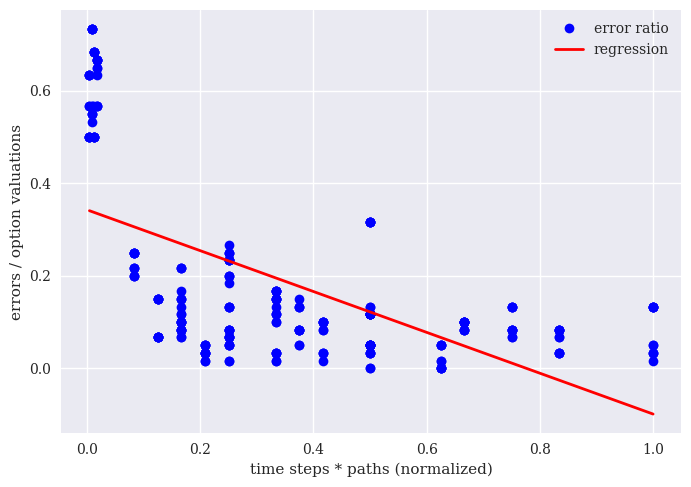

In [33]:
plot_error_ratio(filename)

<p style="font-family: monospace;">Error ratios of Monte Carlo valuation vs. computational effort.

The linear regression illustrates graphically the statement that the higher the computational effort the higher in general the accuracy of the MCS valuations. The high variability of the error ratios stems from the fact that not only the computational effort influences valuation accuracy. For example, the use of variance reduction techniques also has a significant influence.

This being said, one might be interested in analyzing the impact of the variance reduction techniques on the valuation accuracy. To this end, pandas provides powerful grouping methods for the ``DataFrame`` object. First, we open the database in which the simulation results are stored and read them into an in memory object.

In [34]:
import pandas as pd
h5 = pd.HDFStore(filename, 'r')
data = h5['sim_results']
h5.close()

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264 entries, 0 to 95
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   sim_name     264 non-null    object        
 1   seed         264 non-null    int64         
 2   runs         264 non-null    int64         
 3   time_steps   264 non-null    int64         
 4   paths        264 non-null    int64         
 5   mo_match     264 non-null    bool          
 6   anti_paths   264 non-null    bool          
 7   opt_prices   264 non-null    float64       
 8   abs_tol      264 non-null    float64       
 9   rel_tol      264 non-null    float64       
 10  errors       264 non-null    int64         
 11  error_ratio  264 non-null    float64       
 12  aval_err     264 non-null    float64       
 13  abal_err     264 non-null    float64       
 14  time_sec     264 non-null    float64       
 15  time_min     264 non-null    float64       
 16  time_opt     2

The simulation results are stored in 96 rows of the pandas ``DataFrame`` object. The method ``groupby`` allows analyses of such data sets in "all directions and dimensions". For example, one gets the average error ratio depending on the use of moment matching with the following code.

In [36]:
data.groupby(['mo_match'])[['error_ratio']].mean()

,error_ratio
mo_match,
False,0.196528
True,0.166667


In the simulations, moment matching obviously reduces the error ratio by a bit more than 2 percentage points from above 19% to less than 17%.

The same analysis can be done with more data columns, both for the grouping and the output.

In [37]:
data.groupby(['mo_match', 'anti_paths'])[['error_ratio', 'errors']].mean()

error_ratio     errors
mo_match anti_paths                        
False    False          0.206944  12.416667
         True           0.179167  10.750000
True     False          0.159722   9.583333
         True           0.180556  10.833333

Here, the results indicate that moment matching alone should be used. Adding antithetic paths increases the error ratio ceteris paribus.

In similar fashion, the data can be grouped by time steps and paths &mdash; in analogy to the analysis above. The following figure presents the results.

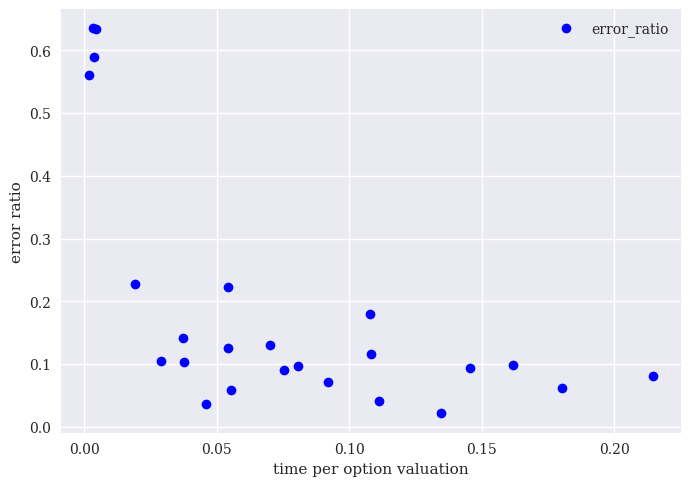

In [38]:
df = data.groupby(['time_steps', 'paths'])[['error_ratio', 'time_opt']].mean()
df.plot(x='time_opt', y='error_ratio', style='bo')
plt.xlabel('time per option valuation')
plt.ylabel('error ratio');

<p style="font-family: monospace;">Error ratios of Monte Carlo valuation vs. time per option.

As expected, the general rule that accuracy increases with increasing computational effort is again supported by this specific analysis. Of course, other analyses can be done with the data generated and stored on disk.

## Model Calibration

Previous sections implement a *theoretical* valuation approach in that a parametric model is given and parameter values are simply *assumed*. However, any realistic valuation of volatility options has to incorporate at least some information from the market itself. This is generally done by taking the quotes of liquidly traded vanilla options as input for a so-called *model calibration*. During the calibration of a financial model, parameters are determined for that model which best replicate the observed option quotes. These parameters are then in turn used to value other, maybe more exotic, derivatives by the means of numerical methods like Monte Carlo simulation. Such a procedure then often is called a *market-based valuation approach*.

This section illustrates how to calibrate the financial model of Gruenbichler and Longstaff (1996) to option quotes for European volatility calls traded at Eurex. In the following, the semi-analytical formula as introduced previously is used to accomplish the model calibration.

### The Option Quotes

The remainder of this section will work with option quotes of VSTOXX call options traded at Eurex which are all of European type. The data is as of 31. March 2014 and contains quotes for the options with maturities for each month from April 2014 to November 2014. Let us have a look at the data.

In [39]:
import pandas as pd
path = './data/'
h5 = pd.HDFStore(path + 'vstoxx_march_2014.h5', 'r')
option_quotes = h5['vstoxx_options']
option_quotes.info()
n = 46244 - 25

<class 'pandas.core.frame.DataFrame'>
Index: 46960 entries, 0 to 46959
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE       46960 non-null  datetime64[ns]
 1   EXP_YEAR   46960 non-null  int64         
 2   EXP_MONTH  46960 non-null  int64         
 3   TYPE       46960 non-null  object        
 4   STRIKE     46960 non-null  float64       
 5   PRICE      46960 non-null  float64       
 6   MATURITY   46960 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2), object(1)
memory usage: 2.9+ MB


In [40]:
option_quotes = option_quotes.iloc[n:n + 98]
option_quotes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 46219 to 46316
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE       98 non-null     datetime64[ns]
 1   EXP_YEAR   98 non-null     int64         
 2   EXP_MONTH  98 non-null     int64         
 3   TYPE       98 non-null     object        
 4   STRIKE     98 non-null     float64       
 5   PRICE      98 non-null     float64       
 6   MATURITY   98 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(2), object(1)
memory usage: 6.1+ KB


As you can see, the data set comprises a total of 98 option quotes. Note that option quotes for Eurex volatility options have tick sizes of 5 Cent, i.e. 0.05 EUR. A detailed overview of the terms of these options can be found on the Web site http://www.eurexchange.com/exchange-de/produkte/vol/. In what follows, we assume that each option is written on a single unit of the underlying, i.e. 1 point of the VSTOXX index translates into 1 EUR.

### The Calibration Procedure

In simple terms, the problem of calibration is to find parameters for an option model such that observed market quotes of liquidly traded plain vanilla options are replicated as good as possible. To this end, one defines an error function that is to be minimized. Such a function could be the *Mean Squared Absolute Error (MSAE)*. The task is then to solve the problem


$$
\min_{\kappa, \theta, \sigma} \frac{1}{N}\sum_{n=1}^{N}\left( C_{n}^{*} - C_{n}^{GL96}(\kappa, \theta, \sigma)\right)^{2}
$$

with the $C_{n}^{*}$ being the market or input prices and the $C_{n}^{GL96}$ being the model or output prices for the options $n=1,...,N$.

For some constellations, it might be more appropriate to minimize the *Mean Squared Relative Error (MSRE)*:

$$
\min_{\kappa, \theta, \sigma} \frac{1}{N}\sum_{n=1}^{N}\left( \frac{C_{n}^{*} - C_{n}^{GL96}(\kappa, \theta, \sigma)}{C_{n}^{*}}\right)^{2}
$$

The Python script (the appendix for the complete code) that implements a procedure to calibrate the Gruenbichler-Longstaff option pricing model is explained in the following step-by-step.

First, some imports and parameter specifications.

In [41]:
!sed -n 11,22p scripts/srd_model_calibration.py

import numpy as np
import pandas as pd
from srd_functions import call_price
import scipy.optimize as sco
import matplotlib.pyplot as plt

path = 'data/'

# Fixed Parameters
v0 = 17.6639  # VSTOXX index on 31. March 2014
r = 0.01  # risk-less short rate
zeta = 0.  # volatility risk premium factor


The function ``read_select_quotes()`` reads and selects option quotes for the calibration.

In [42]:
import srd_model_calibration as smc

In [43]:
smc.read_select_quotes??

Signature: smc.read_select_quotes(path='data/', tol=0.2)
Source:   
def read_select_quotes(path=path, tol=0.2):
    ''' Selects and read options quotes.

    Parameters
    path: string
        path to file with option quotes

    Returns
    option_data: pandas DataFrame object
        option data
    '''
    h5 = pd.HDFStore(path + 'vstoxx_march_2014.h5', 'r')

    # read option data from file and close it
    option_data = h5['vstoxx_options']
    h5.close()
    # transform dates
    option_data['DATE'] = pd.to_datetime(option_data['DATE'])
    option_data['MATURITY'] = pd.to_datetime(option_data['MATURITY'])
    # select relevant date for call option quotes
    option_data = option_data[(option_data.DATE == '2014-3-31')
                            & (option_data.TYPE == 'C')]
    # calculate time-to-maturity in year fractions
    option_data['TTM'] = (option_data.MATURITY - option_data.DATE).apply(
                        lambda x: x / np.timedelta64(1, 'D') / 365.)

    # only tho

However, the core functions of the calibration script are the following. On the one hand, ``valuation_function()``.

In [44]:
smc.valuation_function??

Signature: smc.valuation_function(p0)
Source:   
def valuation_function(p0):
    ''' Valuation function for set of strike prices

    Parameters
    p0: list
        set of model parameters

    Returns
    call_prices: NumPy ndarray object
        array of call prices
    '''
    kappa, theta, sigma = p0
    call_prices = []
    for strike in strikes:
        call_prices.append(call_price(v0, kappa, theta,
                                   sigma, zeta, ttm, r, strike))
    call_prices = np.array(call_prices)
    return call_prices
File:      ~/data/projects/lvvd/code/scripts/srd_model_calibration.py
Type:      function

On the other hand, ``error_function()``.

In [45]:
smc.error_function??

Signature: smc.error_function(p0)
Source:   
def error_function(p0):
    ''' Error function for model calibration.

    Parameters
    p0: tuple
        set of model parameters

    Returns
    MSE: float
        mean squared (relative/absolute) error
    '''
    global i
    call_prices = valuation_function(p0)
    kappa, theta, sigma = p0
    pen = 0.
    if 2 * kappa * theta < sigma ** 2:
        pen = 1000.0
    if kappa < 0 or theta < 0 or sigma < 0:
        pen = 1000.0
    if relative is True:
        MSE = (np.sum(((call_prices - call_quotes) / call_quotes) ** 2)
                / len(call_quotes) + pen)
    else:
        MSE = np.sum((call_prices - call_quotes) ** 2) / len(call_quotes) + pen

    if i == 0:
            print("{:>6s} {:>6s} {:>6s}".format('kappa', 'theta', 'sigma')
                 + "{:>12s}".format('MSE'))

    # print intermediate results: every 100th iteration
    if i % 100 == 0:
        print("{:6.3f} {:6.3f} {:6.3f}".format(*p0) + "{:>12.5f}".format(MSE)

Function ``valuation_function()`` implements a valuation for the array of strikes under consideration and the provided parameter values. Function ``error_function()`` calculates either the MSAE or the MSRE &mdash; given the array of strikes and the parmeter vector ``p0``. Some penalties are also added depending on the single parameter values or their constellation. For details and a number of similar examples, refer to the book Hilpisch (2015, ch. 11).

Then standard functions from the ``scipy.optimize`` library (cf. Hilpisch (2018), ch. 11) are used to implement both a *global* (i.e. via the ``brute()`` function) and a *local optimization* (i.e. via the ``fmin()`` function). This all is wrapped in the function ``model_calibration()``.

In [46]:
smc.model_calibration??

Signature: smc.model_calibration(option_data, rel=False, mat='2014-07-18')
Source:   
def model_calibration(option_data, rel=False, mat='2014-07-18'):
    ''' Function for global and local model calibration.

    Parameters
    option_data: pandas DataFrame object
        option quotes to be used
    relative: boolean
        relative or absolute MSE
    maturity: string
        maturity of option quotes to calibrate to

    Returns
    opt: tuple
        optimal parameter values
    '''
    global relative  # if True: MSRE is used, if False: MSAE
    global strikes
    global call_quotes
    global ttm
    global i

    relative = rel
    # only option quotes for a single maturity
    option_quotes = option_data[option_data.MATURITY == mat]

    # time-to-maturity from the data set
    ttm = option_quotes.iloc[0, -1]

    # transform strike column and price column in ndarray object
    strikes = option_quotes['STRIKE'].values
    call_quotes = option_quotes['PRICE'].values

    # glob

Finally, the results are visualized by plotting the model values against the market values and providing the absolute differences separately. This is accomplished by the function ``plot_calibration_results()``.

In [47]:
smc.plot_calibration_results??

Signature: smc.plot_calibration_results(opt)
Source:   
def plot_calibration_results(opt):
    ''' Function to plot market quotes vs. model prices.

    Parameters
    opt: list
        optimal parameters from calibration
    '''
    callalues = valuation_function(opt)
    diffs = callalues - call_quotes
    plt.figure()
    plt.subplot(211)
    plt.plot(strikes, call_quotes, label='market quotes')
    plt.plot(strikes, callalues, 'ro', label='model prices')
    plt.ylabel('option values')
    plt.grid(True)
    plt.legend()
    plt.axis([min(strikes) - 0.5, max(strikes) + 0.5,
          0.0, max(call_quotes) * 1.1])
    plt.subplot(212)
    wi = 0.3
    plt.bar(strikes, diffs, width=wi)
    plt.grid(True)
    plt.xlabel('strike price')
    plt.ylabel('difference')
    plt.axis([min(strikes) - 0.5, max(strikes) + 0.5,
          min(diffs) * 1.1, max(diffs) * 1.1])
    plt.tight_layout()
File:      ~/data/projects/lvvd/code/scripts/srd_model_calibration.py
Type:      function

### The Calibration Results

We start with a calibration run for the option quotes with the shorter maturity and using the *MSAE* as yardstick.

In [48]:
from srd_model_calibration import *
option_data = read_select_quotes()

In [49]:
option_data.head()

,DATE,EXP_YEAR,EXP_MONTH,TYPE,STRIKE,PRICE,MATURITY,TTM
46184,2014-03-31,2014,4,C,15.0,2.90,2014-04-18,0.049315
46185,2014-03-31,2014,4,C,16.0,2.00,2014-04-18,0.049315
46186,2014-03-31,2014,4,C,17.0,1.35,2014-04-18,0.049315
46187,2014-03-31,2014,4,C,18.0,0.95,2014-04-18,0.049315
46188,2014-03-31,2014,4,C,19.0,0.70,2014-04-18,0.049315


In [50]:
%time opt = model_calibration(option_data, rel=False, mat='2014-05-16')

 kappa  theta  sigma         MSE
 5.000 10.000  1.000     7.78544
 6.000 13.750  1.000     6.76149
 7.000 17.500  1.000     3.54918
 8.000 21.250  1.000     0.57006
 9.000 25.000  1.000     5.05665
10.000 28.750  1.000    25.88197
12.000 11.250  1.000     7.95107
13.000 15.000  1.000     7.05474
14.000 18.750  1.000     1.98105
15.000 22.500  1.000     2.26185
16.000 26.250  1.000    21.14724
17.000 30.000  1.000    63.94116
19.000 12.500  1.000     7.95132
20.000 16.250  1.000     5.93338
 kappa  theta  sigma         MSE
15.000 18.750  7.000     0.01356
16.381 19.112  6.613     0.00834
25.372 18.983  8.150     0.00831
38.133 18.941  9.973     0.00831
44.838 18.935 10.810     0.00831
48.637 18.934 11.258     0.00831
52.095 18.933 11.651     0.00831
54.132 18.932 11.876     0.00831
56.665 18.932 12.151     0.00831
59.386 18.932 12.439     0.00831
61.202 18.931 12.628     0.00831
62.828 18.931 12.794     0.00831
64.446 18.931 12.958     0.00831
65.539 18.931 13.067     0.00831
66.513 18.

/Users/tuan/data/projects/lvvd/code/scripts/srd_model_calibration.py:160: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  opt = sco.fmin(error_function, p0, xtol=0.0000001, ftol=0.0000001,


The following figure shows the calibration results.

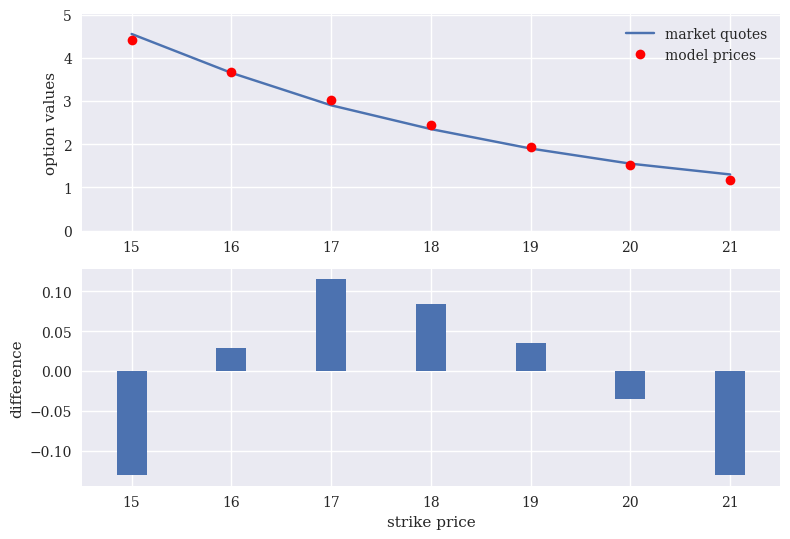

In [51]:
plot_calibration_results(opt)

<p style="font-family: monospace;">Calibration of option pricing model to option quotes for May 2014 maturity with MSAE.

Now the calibration to the option quotes with a longer time-to-maturity and using the *MSRE* as yardstick.

In [52]:
%time opt = model_calibration(option_data, rel=True, mat='2014-07-18')

 kappa  theta  sigma         MSE
 5.000 10.000  1.000     0.99994
 6.000 13.750  1.000     0.98657
 7.000 17.500  1.000     0.74427
 8.000 21.250  1.000     0.15574
 9.000 25.000  1.000     0.71077
10.000 28.750  1.000     4.09931
12.000 11.250  1.000     1.00000
13.000 15.000  1.000     0.98062
14.000 18.750  1.000     0.57102
15.000 22.500  1.000     0.09463
16.000 26.250  1.000     1.88722
17.000 30.000  1.000     6.70269
19.000 12.500  1.000     1.00000
20.000 16.250  1.000     0.91588
 kappa  theta  sigma         MSE
 5.000 20.000  5.000     0.00051
 5.806 19.923  5.284     0.00050
 9.269 19.659  6.551     0.00050
14.406 19.568  8.120     0.00049
16.640 19.555  8.723     0.00049
18.575 19.549  9.216     0.00049
20.193 19.547  9.608     0.00049
21.107 19.546  9.822     0.00049
21.929 19.545 10.011     0.00049
22.698 19.544 10.185     0.00049
23.344 19.544 10.329     0.00049
24.021 19.543 10.478     0.00049
24.695 19.543 10.624     0.00049
25.182 19.543 10.728     0.00049
25.668 19.

The results of this calibration run are shown in the following figure.

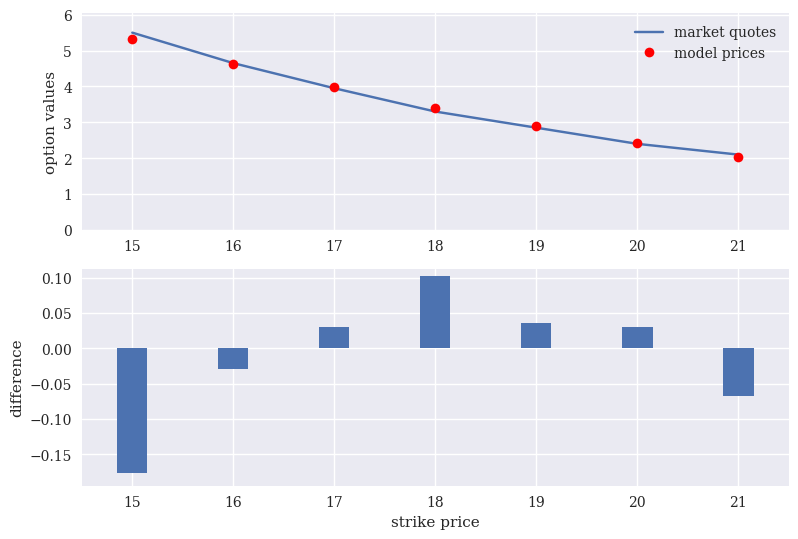

In [53]:
plot_calibration_results(opt)

<p style="font-family: monospace;">Calibration of option pricing model to option quotes for July 2014 maturity  with MSRE.

Neither of the two fits is satisfactory for such small sets of option prices. The differences are often higher than the tick size of 5 Cent. Therefore, this model obviously does not paint a too realistic picture of the real world. This may be due to the underlying, i.e. the VSTOXX volatilty index, exhibiting more and/or other properties than the ones captured in the model of Gruenbichler and Longstaff (1996). For example, a well documented stylized fact is that time series of volatility indexes, like the VSTOXX, exhibit (positive) *jumps* of significant size and with significant probability. Something that is, for example, not captured in the pricing model used in this chapter.

## Conclusions

Volatility derivatives, like futures and options on a volatility index, and their arbitrage-free valuation are the focus of this chapter. The model of Gruenbichler and Longstaff (1996) is introduced since it serves pretty well as a benchmark case &mdash; due to its simplicity &mdash; for volatility modeling and volatility derivatives valuation. The model uses a square-root diffusion or CIR process to describe the evolution of volatility (indexes) over time. Futures and European call option pricing formulas are presented. Based on an exact discretization scheme, Monte Carlo simulation is described as an alternative numerical pricing method. In addition, Python code to implement automated Monte Carlo simulation studies is provided and used for such a study. Finally, the GL96 model is calibrated to market quotes for European call options on the VSTOXX volatility index. The results illustrate that the model might not be rich enough to account for market realities.

## Python Scripts

### ``srd_functions.py``

In [54]:
!cat scripts/srd_functions.py

#
# Module with functions for
# Gruenbichler and Longstaff (1996) model
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import math
import numpy as np
import scipy.stats as scs


def futures_price(v0, kappa, theta, zeta, T):
    ''' Futures pricing formula in GL96 model.

    Parameters
    v0: float (positive)
        current volatility level
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean of volatility
    zeta: float (positive)
        volatility risk premium
    T: float (positive)
        time-to-maturity

    Returns
    future: float
        price of a future
    '''
    alpha = kappa * theta
    beta = kappa + zeta
    future = (alpha / beta * (1 - math.exp(-beta * T))
                               + math.exp(-beta * T) * v0)
    return future


def cx(K, gamma, nu, lamb):
    ''' Complementary distribution function of non-central chi-squared density.

    Parameters
    K: float (positive)

### ``srd_simulation_analysis.py``

In [55]:
!cat scripts/srd_simulation_analysis.py

#
# Valuation of European volatility options
# by Monte Carlo simulation in
# Gruenbichler and Longstaff (1996) model
# -- analysis of valuation results
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import time
import math
import numpy as np
from datetime import datetime
from srd_functions import generate_paths, call_price
from srd_simulation_results import *

# Model Parameters
v0 = 20.0  # initial volatility
kappa = 3.0  # speed of mean reversion
theta = 20.0  # long-term volatility
sigma = 3.2  # standard deviation coefficient
zeta = 0.0  # factor of the expected volatility risk premium
r = 0.01  # risk-free short rate

# General Simulation Parameters
write = True
var_red = [(False, False), (False, True), (True, False), (True, True)]
    # 1st = mo_match -- random number correction (std + mean + drift)
    # 2nd = anti_paths -- antithetic paths for variance reduction
# number of time steps
steps_list = [25, 50, 75, 100]
# number of paths per valuation
p

### ``srd_simulation_results.py``

In [56]:
!cat scripts/srd_simulation_results.py

#
# Valuation of European volatility options
# by Monte Carlo simulation in
# Gruenbichler and Longstaff (1996) model
# -- Creating a database for simulation results
# with pandas and PyTables
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# filname for HDFStore to save results
filename = "data/simulation_results.h5"


def write_results(sim_results, name, SEED, runs, steps, paths, mo_match,
                  anti_paths, l, PY1, PY2, errors, error_ratio,
                  abs_errors, rel_errors, t1, t2, d1, d2):
    ''' Appends simulation results to pandas DataFrame df and returns it.

    Parameters
    see srd_simulation_analysis.py

    Returns
    df: pandas DataFrame object
        updated results object
    '''
    results = {
    'sim_name': name,
    'seed': SEED,
    'runs': runs,
    'time_steps': steps,
    'paths': paths,
    'mo_match': mo_match,
    'a

### ``srd_model_calibration.py``

In [57]:
!cat scripts/srd_model_calibration.py

#
# Calibration of Gruenbichler and Longstaff (1996)
# square-root diffusion model to
# VSTOXX call options traded at Eurex
# Data as of 31. March 2014
# All data from www.eurexchange.com
#
# (c) Dr. Yves J. Hilpisch
# Listed Volatility and Variance Derivatives
#
import numpy as np
import pandas as pd
from srd_functions import call_price
import scipy.optimize as sco
import matplotlib.pyplot as plt

path = 'data/'

# Fixed Parameters
v0 = 17.6639  # VSTOXX index on 31. March 2014
r = 0.01  # risk-less short rate
zeta = 0.  # volatility risk premium factor


def read_select_quotes(path=path, tol=0.2):
    ''' Selects and read options quotes.

    Parameters
    path: string
        path to file with option quotes

    Returns
    option_data: pandas DataFrame object
        option data
    '''
    h5 = pd.HDFStore(path + 'vstoxx_march_2014.h5', 'r')

    # read option data from file and close it
    option_data = h5['vstoxx_options']
    h5.close()
    # transform dates
    option_data['

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>